<a href="https://colab.research.google.com/github/peetpeet19/project_dstoolbox/blob/main/%E0%B8%9E%E0%B8%B5%E0%B8%97%E0%B8%97%E0%B8%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

import plotly
import plotly.graph_objs as go

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import pickle as p

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense
from keras import backend as K

In [ ]:
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
import tensorflow_datasets as tfds

In [ ]:
import zipfile
unzip = zipfile.ZipFile("/content/drive/MyDrive/P_data_sum.zip", 'r')
unzip.extractall('sum')

In [ ]:
batch_size = 40
num_classes = 2
epochs = 30

img_rows, img_cols = 28, 28

input_shape = (img_rows, img_cols, 1)

In [ ]:
from keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
# create a data generator
datagen = ImageDataGenerator(rescale=1.0/255.0)

In [ ]:
# color_mode='rgb'
# color_mode='grayscale'
train_it = datagen.flow_from_directory('/content/sum/train', target_size=(28, 28), batch_size=batch_size, class_mode='categorical', shuffle=False, color_mode='grayscale')
val_it = datagen.flow_from_directory('/content/sum/test', target_size=(28, 28), batch_size=batch_size, class_mode='categorical', shuffle=False, color_mode='grayscale')

Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.


In [ ]:
batchX, batchy = train_it.next()
print('Batch shape=%s, min=%.3f, max=%.3f' % (batchX.shape, batchX.min(), batchX.max()))

Batch shape=(40, 28, 28, 1), min=0.000, max=1.000


In [ ]:
batchy

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]], dtype=float32)

In [ ]:
print('Batch shape=%s, min=%.3f, max=%.3f' % (batchX.shape, batchX.min(), batchX.max()))

Batch shape=(40, 28, 28, 1), min=0.000, max=1.000


In [ ]:
#Feature Extraction
model = tf.keras.Sequential()
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(tf.keras.layers.Dropout(0.25))

#Image Classification
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_4 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 24, 24, 64)        18496     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 12, 12, 64)        0         
_________________________________________________________________
dropout_4 (Dropout)          (None, 12, 12, 64)        0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 9216)              0         
_________________________________________________________________
dense_4 (Dense)              (None, 128)               1179776   
_________________________________________________________________
dropout_5 (Dropout)          (None, 128)              

In [ ]:
STEP_SIZE_TRAIN=train_it.n//train_it.batch_size
STEP_SIZE_VALID=val_it.n//val_it.batch_size
his = model.fit(train_it,
                    steps_per_epoch=STEP_SIZE_TRAIN,
                    validation_data=val_it,
                    validation_steps=STEP_SIZE_VALID,
                    epochs=epochs
)

Epoch 1/30


/usr/local/lib/python3.7/dist-packages/PIL/Image.py:960: UserWarning:

Palette images with Transparency expressed in bytes should be converted to RGBA images



40/40 [==============================] - 101s 3s/step - loss: 0.9399 - accuracy: 0.4994 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 2/30
40/40 [==============================] - 99s 2s/step - loss: 0.6933 - accuracy: 0.5050 - val_loss: 0.6922 - val_accuracy: 0.5025
Epoch 3/30
40/40 [==============================] - 100s 3s/step - loss: 0.6931 - accuracy: 0.4944 - val_loss: 0.6866 - val_accuracy: 0.6425
Epoch 4/30
40/40 [==============================] - 100s 2s/step - loss: 0.6891 - accuracy: 0.5550 - val_loss: 0.6655 - val_accuracy: 0.6475
Epoch 5/30
40/40 [==============================] - 100s 3s/step - loss: 0.6441 - accuracy: 0.6581 - val_loss: 0.5886 - val_accuracy: 0.7550
Epoch 6/30
40/40 [==============================] - 100s 2s/step - loss: 0.5453 - accuracy: 0.7625 - val_loss: 0.6367 - val_accuracy: 0.5850
Epoch 7/30
40/40 [==============================] - 100s 2s/step - loss: 0.5909 - accuracy: 0.6819 - val_loss: 0.5435 - val_accuracy: 0.7100
Epoch 8/30
40/40 [=======

In [ ]:
h1 = go.Scatter(y=his.history['loss'], 
                    mode="lines", line=dict(
                    width=2,
                    color='blue'),
                    name="loss"
                   )
h2 = go.Scatter(y=his.history['val_loss'], 
                    mode="lines", line=dict(
                    width=2,
                    color='red'),
                    name="val_loss"
                   )
                   
data = [h1,h2]
layout1 = go.Layout(title='Loss',
                   xaxis=dict(title='epochs'),
                   yaxis=dict(title=''))
fig1 = go.Figure(data, layout=layout1)
plotly.offline.iplot(fig1, filename="Classification")

In [ ]:
h1 = go.Scatter(y=his.history['accuracy'], 
                    mode="lines",
                    line=dict(
                        width=2,
                        color='blue'),
                    name="acc"
                   )
h2 = go.Scatter(y=his.history['val_accuracy'], 
                    mode="lines",
                    line=dict(
                        width=2,
                        color='red'),
                    name="val_acc"
                   )

data = [h1,h2]
layout1 = go.Layout(title='Accuracy',
                   xaxis=dict(title='Epochs'),
                   yaxis=dict(title=''))
fig1 = go.Figure(data = data, layout=layout1)
plotly.offline.iplot(fig1, filename='Underfit')

In [ ]:
predicted_classes = model.predict(val_it, steps=STEP_SIZE_VALID)
predicted_classes

/usr/local/lib/python3.7/dist-packages/PIL/Image.py:960: UserWarning:

Palette images with Transparency expressed in bytes should be converted to RGBA images



array([[9.98905420e-01, 1.09459669e-03],
       [9.99825656e-01, 1.74347893e-04],
       [9.99184072e-01, 8.15875421e-04],
       [9.99676228e-01, 3.23773391e-04],
       [9.99926448e-01, 7.35284193e-05],
       [9.99999046e-01, 9.80789082e-07],
       [9.99773443e-01, 2.26511896e-04],
       [9.98741210e-01, 1.25882099e-03],
       [9.99999046e-01, 1.01021112e-06],
       [9.99792516e-01, 2.07536912e-04],
       [1.00000000e+00, 1.07424780e-08],
       [9.99409914e-01, 5.90152224e-04],
       [9.98908401e-01, 1.09163206e-03],
       [9.99999523e-01, 4.81501900e-07],
       [9.99922752e-01, 7.71868654e-05],
       [9.99997854e-01, 2.18759578e-06],
       [9.99756038e-01, 2.43911665e-04],
       [9.99562800e-01, 4.37209790e-04],
       [9.99379873e-01, 6.20156934e-04],
       [9.99997258e-01, 2.73307228e-06],
       [9.99856472e-01, 1.43508558e-04],
       [9.99948859e-01, 5.10934333e-05],
       [9.99867439e-01, 1.32488189e-04],
       [1.15557285e-07, 9.99999881e-01],
       [9.999121

In [ ]:
predicted_classes = np.argmax(predicted_classes,axis=-1)
predicted_classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
true_classes = val_it.classes
true_classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
class_labels = list(val_it.class_indices.keys())  
class_labels

['flowers', 'foods']

In [ ]:
report = classification_report(true_classes, predicted_classes, target_names=class_labels, digits=4)

In [ ]:
print(report)

              precision    recall  f1-score   support

     flowers     0.9900    0.9900    0.9900       200
       foods     0.9900    0.9900    0.9900       200

    accuracy                         0.9900       400
   macro avg     0.9900    0.9900    0.9900       400
weighted avg     0.9900    0.9900    0.9900       400



# **ไม่ต้องสนใจด้านล่าง มันเป็นการทดลองงงงงงงงงงง**

In [ ]:
train_data_dir = '/content/drive/MyDrive/data/train'
validation_data_dir = '/content/drive/MyDrive/data/validation'
nb_train_samples = 500
nb_validation_samples = 50
epochs = 2
batch_size = 16

if K.image_data_format() == 'channels_first':
    input_shape = (3, img_width, img_height)
else:
    input_shape = (img_width, img_height, 3)

model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=input_shape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

# this is the augmentation configuration we will use for testing:
# only rescaling
test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary')

model.fit_generator(
    train_generator,
    steps_per_epoch=nb_train_samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=nb_validation_samples // batch_size)

model.save_weights('first_try.h5')


Found 1506 images belonging to 2 classes.
Found 1506 images belonging to 2 classes.


/usr/local/lib/python3.7/dist-packages/keras/engine/training.py:1915: UserWarning:

`Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.



Epoch 1/2
31/31 [==============================] - 20s 652ms/step - loss: 0.5820 - accuracy: 0.7157 - val_loss: 0.5274 - val_accuracy: 0.7708
Epoch 2/2
31/31 [==============================] - 19s 622ms/step - loss: 0.6126 - accuracy: 0.6867 - val_loss: 0.5232 - val_accuracy: 0.7708


แก้ๆๆ


In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"peetornthong","key":"cc20ae63002c6bfcffb1a3acce2b1960"}'}

In [ ]:
!mkdir kaggle

In [ ]:
!mv kaggle.json kaggle

In [ ]:
!chmod 600 /content/kaggle/kaggle.json

In [ ]:
import os

os.environ['KAGGLE_CONFIG_DIR'] = "/content/kaggle"

In [ ]:
!kaggle datasets download -d ramjanamyadav/food-vs-flower-datasets

 98% 761M/776M [00:06<00:00, 117MB/s]
100% 776M/776M [00:06<00:00, 117MB/s]


In [ ]:
import zipfile

unzip = zipfile.ZipFile('/content/food-vs-flower-datasets.zip', 'r')
unzip.extractall('sum')

In [ ]:
import glob
image_path = glob.glob('/content/sum/train/train/*/*.jpg')
len(image_path)

1508

In [ ]:
to_categorical = tf.keras.utils.to_categorical
make = tf.keras.preprocessing.image_dataset_from_directory('/content/make/data')
load_model = tf.keras.models.load_model
model_from_json = tf.keras.models.model_from_json

Found 3012 files belonging to 3 classes.


In [ ]:
import os
from PIL import Image
import numpy

myimages = []
for dirname, _, filenames in os.walk('/content/make/data/data'):    
    for filename in filenames:
            img=Image.open(os.path.join(dirname, filename))
            imgarray=numpy.array(img)
            myimages.append(imgarray)

In [ ]:
len(myimages)
print("there are {} images avaliable.".format(len(myimages)))

there are 1506 images avaliable.


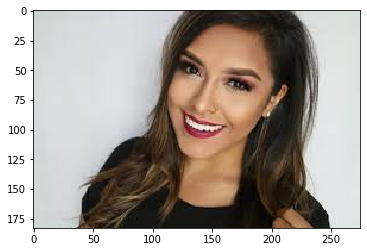

In [ ]:
from matplotlib import pyplot as plt
img1=Image.open("/content/make/data/makeup/makeup0.jpeg")
attemp=numpy.array(img1)
plt.imshow(attemp, interpolation='nearest')
plt.show()

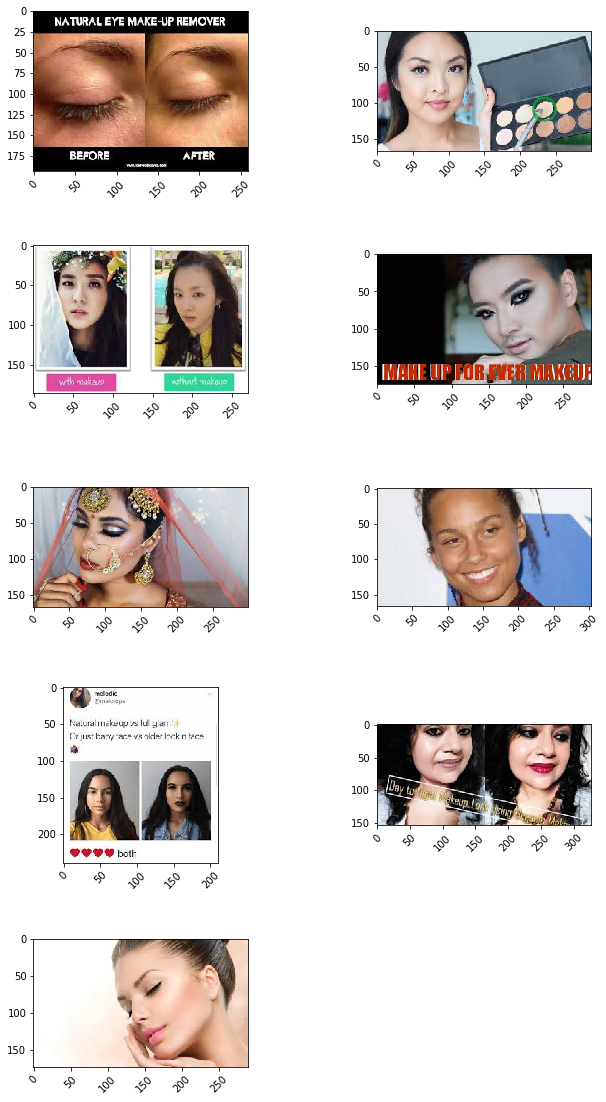

In [ ]:
fig = plt.figure(figsize=(10,20))
fig.subplots_adjust(hspace=0.3, wspace=0.6)
for i in range(1, 10):
    ax = fig.add_subplot(5, 2, i)
    plt.imshow(myimages[i-1], interpolation='nearest')
    plt.xticks(rotation=45)